In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder , StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [5]:
data = pd.read_csv("Housing.csv")

In [6]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
data.dropna(inplace = True)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [10]:
X = data.drop(['median_house_value'], axis = 1)
y = data['median_house_value']

In [11]:
X_train , X_test, y_train, y_test = train_test_split(
    X, y , test_size = 0.2
)

In [12]:
train_data = X_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
987,-121.82,37.73,47.0,127.0,23.0,51.0,21.0,4.3472,INLAND,375000.0
5071,-118.31,33.99,49.0,857.0,196.0,694.0,228.0,2.8950,<1H OCEAN,108000.0
3540,-118.49,34.26,25.0,8389.0,1872.0,4483.0,1747.0,3.5497,<1H OCEAN,261300.0
2977,-119.06,35.32,15.0,3944.0,746.0,2355.0,757.0,3.5690,INLAND,70700.0
2367,-119.56,36.71,29.0,1963.0,392.0,1208.0,398.0,2.5741,INLAND,73000.0
...,...,...,...,...,...,...,...,...,...,...
5474,-118.46,33.99,44.0,1122.0,287.0,531.0,256.0,4.0598,<1H OCEAN,335900.0
5457,-118.47,34.00,41.0,2331.0,636.0,1839.0,537.0,2.2880,<1H OCEAN,263500.0
18338,-122.15,37.44,52.0,1945.0,293.0,708.0,275.0,6.1655,NEAR BAY,500001.0
16080,-122.49,37.74,52.0,2442.0,449.0,1188.0,436.0,4.3909,NEAR OCEAN,317700.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

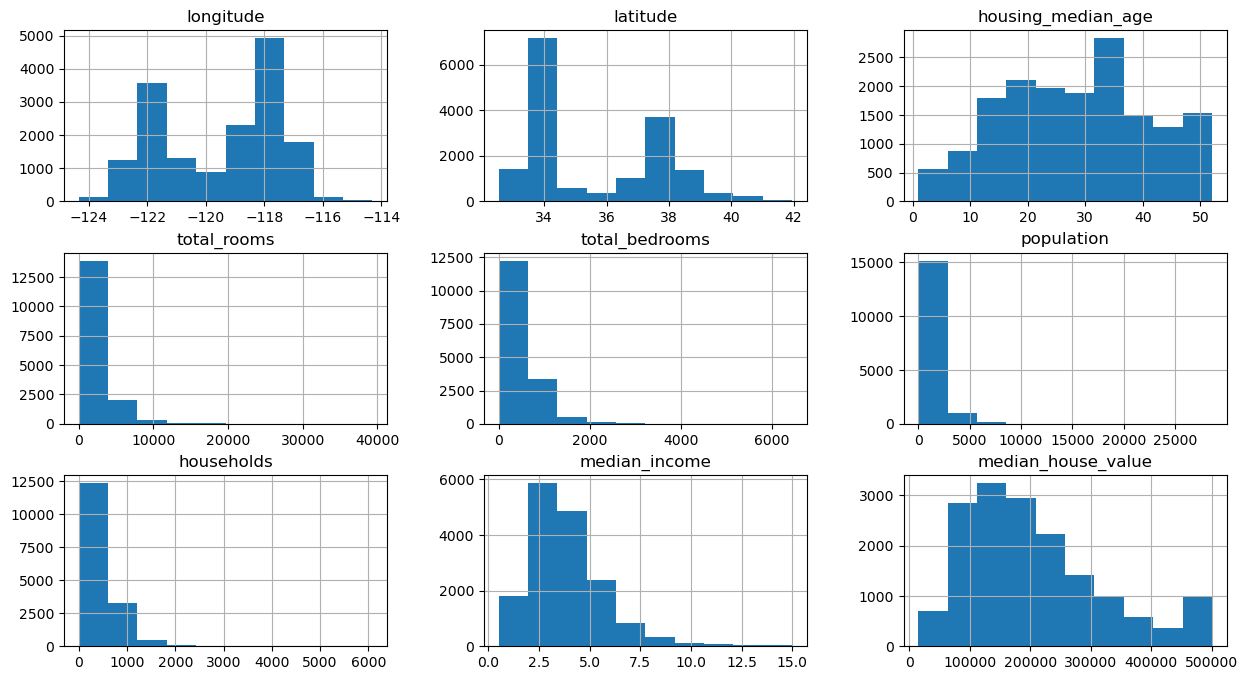

In [13]:
train_data.hist(figsize=(15,8))

In [14]:
#numeric_data = train_data.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(numeric_only = True), annot=True, cmap="YlGnBu")
plt.show()

NameError: name 'numeric_data' is not defined

<Figure size 1000x600 with 0 Axes>

In [15]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

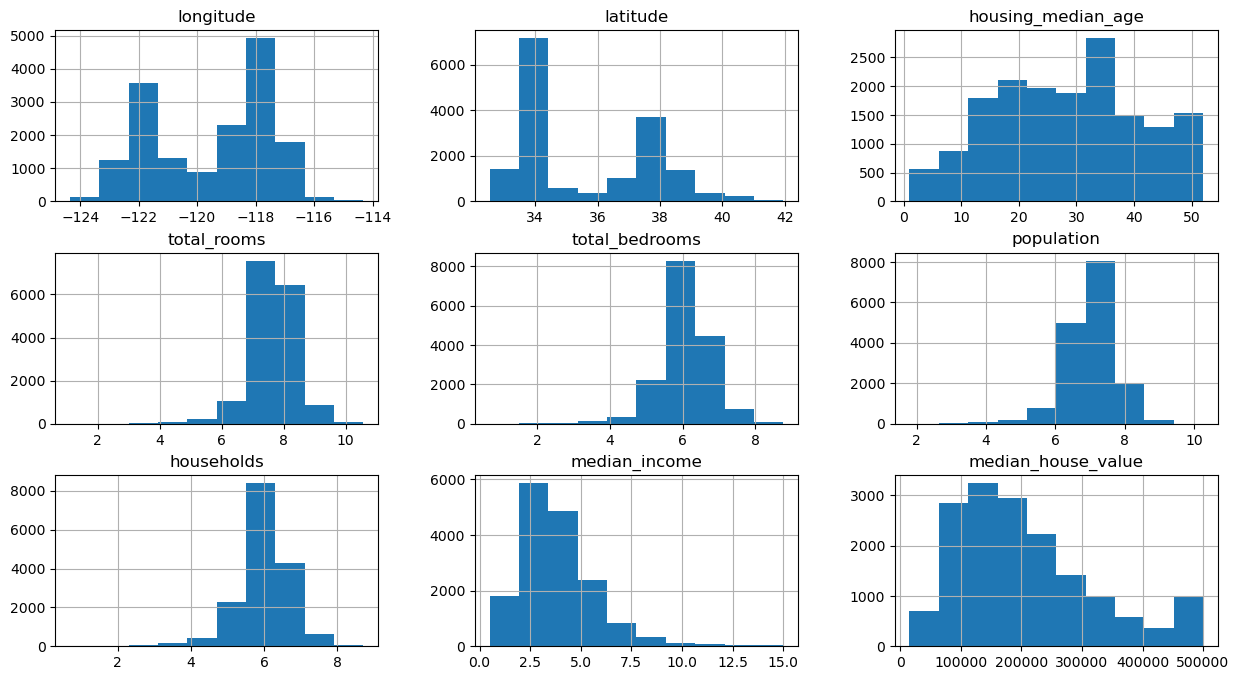

In [16]:
train_data.hist(figsize=(15,8))

In [17]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7225
INLAND        5206
NEAR OCEAN    2093
NEAR BAY      1818
ISLAND           4
Name: count, dtype: int64

In [18]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(['ocean_proximity'], axis = 1)

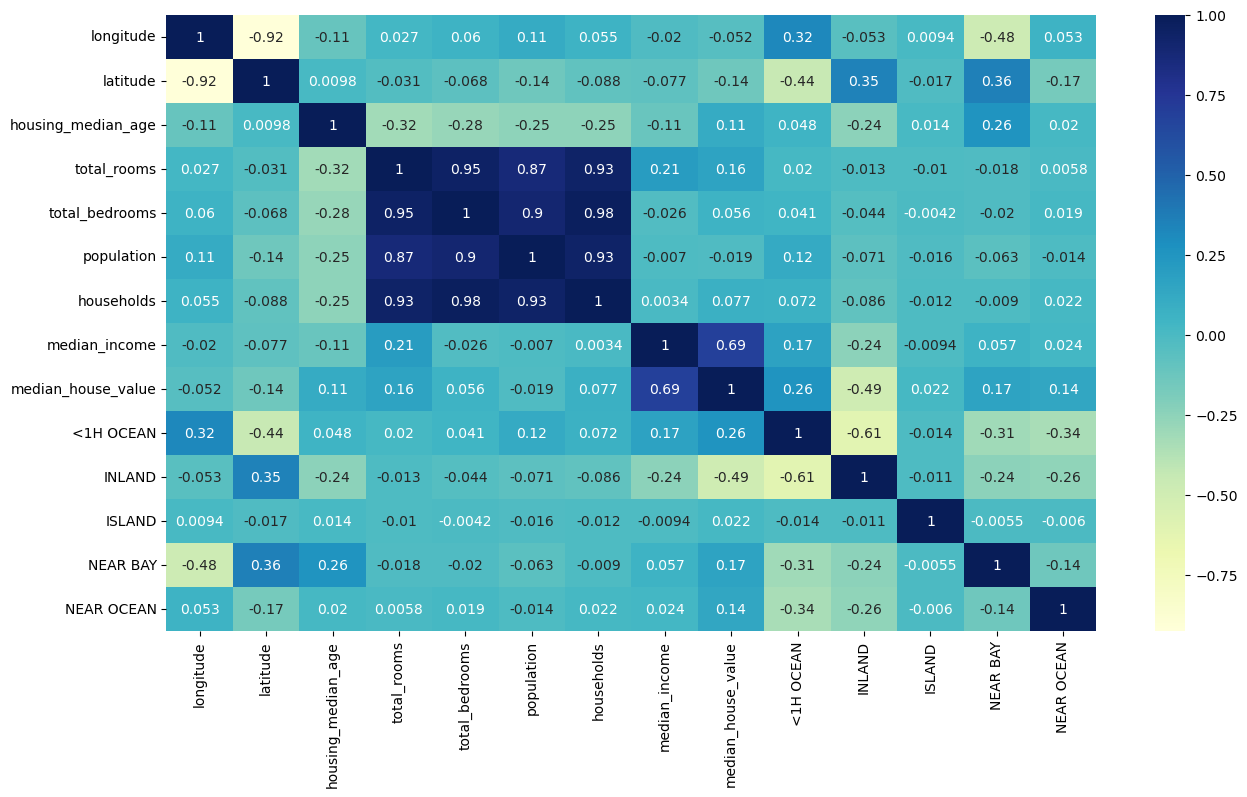

In [21]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")
plt.show()

<Axes: xlabel='latitude', ylabel='longitude'>

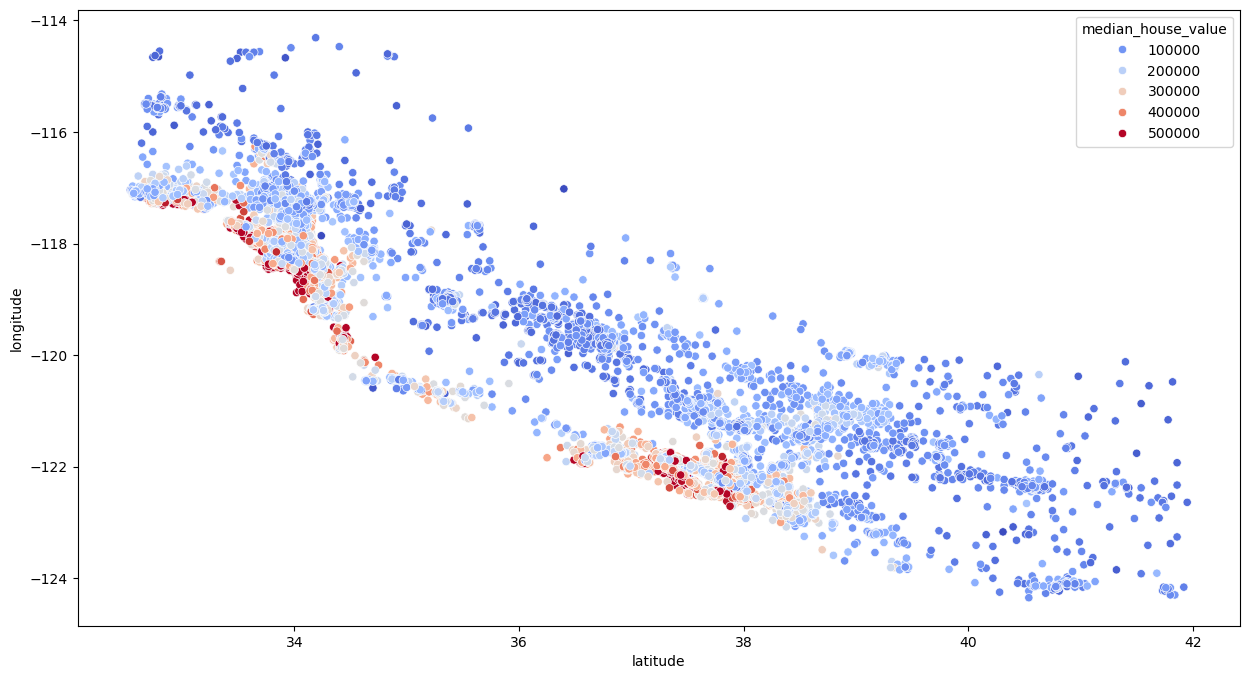

In [23]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = "latitude", y = "longitude", data = train_data ,hue="median_house_value", palette = "coolwarm")

In [24]:
train_data['bedrooms_ration'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

In [37]:
scaler = StandardScaler()
reg = LinearRegression()
X_train, y_train = train_data.drop(['median_house_value'], axis = 1), train_data['median_house_value']
x_train = scaler.fit_transform(X_train)
reg.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

#test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(['ocean_proximity'], axis=1)

test_data['bedrooms_ration'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']


In [40]:
X_test, y_test = test_data.drop(['median_house_value'], axis = 1), test_data['median_house_value']

In [41]:
x_test = scaler.fit_transform(X_test)

In [42]:
reg.score(x_test, y_test)

0.6661613477161277

In [50]:
forest = RandomForestRegressor()
forest.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
forest.score(x_test, y_test)

0.7381817180757775